In [24]:
# Load all MTurk decision files and concatenate
import pandas as pd
from glob import glob
import numpy as np

base_dir = '../mturk/data/results/False-publish-2025-*'
decision_files = sorted(glob(f'{base_dir}/decisions.csv'))
print(f'Found {len(decision_files)} decision files')

decisions = pd.concat([pd.read_csv(f) for f in decision_files], ignore_index=True)
print(f'Total decisions: {len(decisions)}')

Found 22 decision files
Total decisions: 186


In [25]:
# Remove rejected submissions
print(decisions[decisions['decision'] == 'reject'].shape)
decisions = decisions[decisions['decision'] != 'reject']

(2, 21)


In [26]:
# Remove specific worker contribution (story 11340, worker A38NFX88VZDMJ3)
decisions = decisions[~((decisions['story_id'] == 11340) & (decisions['worker_id'] == 'A38NFX88VZDMJ3'))]

In [27]:
decisions.shape

(183, 21)

In [28]:
# Add total story count per worker
decisions['worker_total_stories'] = decisions.groupby('worker_id')['story_id'].transform('count')

In [29]:
# Select 3 workers per story, prioritizing those with fewer total contributions
def select_diverse_workers(group):
    if len(group) <= 3:
        return group
    group = group.copy()
    group['random_tie_breaker'] = np.random.random(len(group))
    return group.sort_values(['worker_total_stories', 'random_tie_breaker']).head(3)

In [30]:
# Apply worker selection and clean up helper columns
np.random.seed(42)
decisions = (decisions.groupby('story_id', group_keys=False)
                      .apply(select_diverse_workers, include_groups=False)
                      .drop(columns=['worker_total_stories', 'random_tie_breaker'])
                      .reset_index(drop=True))

WORKER STATISTICS
Total unique workers: 55
Total tasks completed: 180
Average tasks per worker: 3.27
Standard deviation: 1.69
Min tasks per worker: 1
Max tasks per worker: 8


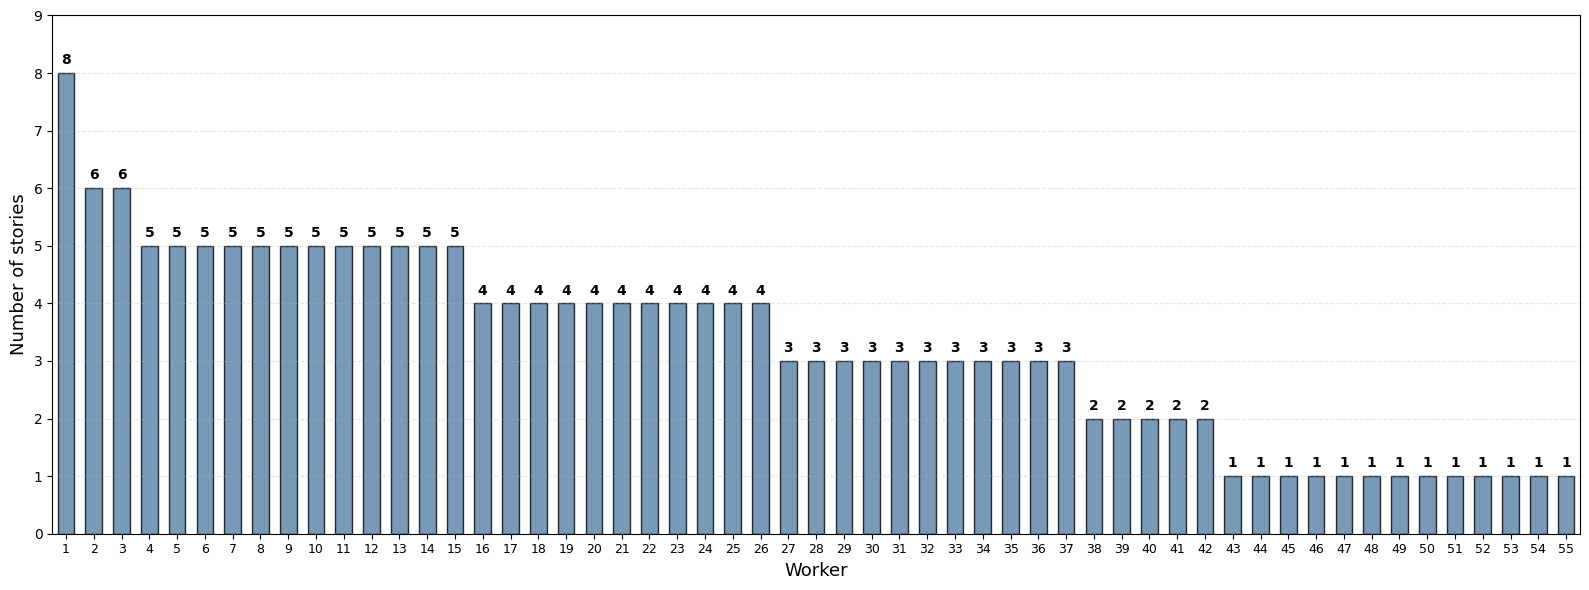


Figure saved as '/mimer/NOBACKUP/groups/naiss2025-22-1187/coherence-driven-humans/figures/worker_distribution.pdf'


In [31]:
# Worker distribution statistics
import matplotlib.pyplot as plt
import seaborn as sns

worker_counts = decisions['worker_id'].value_counts().sort_values(ascending=False)

print("="*50)
print("WORKER STATISTICS")
print("="*50)
print(f"Total unique workers: {len(worker_counts)}")
print(f"Total tasks completed: {len(decisions)}")
print(f"Average tasks per worker: {worker_counts.mean():.2f}")
print(f"Standard deviation: {worker_counts.std():.2f}")
print(f"Min tasks per worker: {worker_counts.min()}")
print(f"Max tasks per worker: {worker_counts.max()}")
print("="*50)

# Create anonymized bar chart
fig, ax = plt.subplots(figsize=(16, 6))
x_pos = range(len(worker_counts))

sns.barplot(x=list(x_pos), y=worker_counts.values, color='steelblue', edgecolor='black', 
            alpha=0.8, ax=ax, width=0.6)

for i, count in enumerate(worker_counts.values):
    ax.text(i, count + 0.1, str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Worker', fontsize=13)
ax.set_ylabel('Number of stories', fontsize=13)
ax.set_xticks(x_pos)
ax.set_xticklabels([i+1 for i in x_pos], fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, worker_counts.max() + 1)

plt.tight_layout()
output_path = '/mimer/NOBACKUP/groups/naiss2025-22-1187/coherence-driven-humans/figures/worker_distribution.pdf'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nFigure saved as '{output_path}'")

In [32]:
# Payment and word count statistics
def count_words(text_list):
    total = 0
    for text in text_list:
        if isinstance(text, str) and text.strip():
            total += len(text.strip().split())
    return total

payment_data = []
for idx, row in decisions.iterrows():
    text_cols = [f'text{i}' for i in range(10)]
    texts = [row[col] for col in text_cols if col in decisions.columns and col in row.index and pd.notna(row[col]) and isinstance(row[col], str) and row[col].strip()]
    
    word_count = count_words(texts)
    base_payment = 4.00
    word_payment = round(word_count * 0.04, 2)
    total_payment = base_payment + word_payment
    
    payment_data.append({
        'word_count': word_count,
        'base_payment': base_payment,
        'word_payment': word_payment,
        'total_payment': total_payment
    })

payment_df = pd.DataFrame(payment_data)

# Payment statistics
total_base = payment_df['base_payment'].sum()
total_word_based = payment_df['word_payment'].sum()
subtotal = payment_df['total_payment'].sum()

# MTurk fees breakdown:
# - 20% fee on base reward
# - 20% fee on bonus payment
# - 5% Masters qualification fee (on base reward only)
base_fee = total_base * 0.20  # 20% on base reward
bonus_fee = total_word_based * 0.20  # 20% on bonus
masters_fee = total_base * 0.05  # 5% Masters fee on base reward
total_fees = base_fee + bonus_fee + masters_fee
total_cost = subtotal + total_fees

print("="*60)
print("PAYMENT STATISTICS")
print("="*60)
print(f"Total descriptions: {len(payment_df)}")
print(f"\nWord Count Statistics:")
print(f"  Mean words per description: {payment_df['word_count'].mean():.2f}")
print(f"  Standard deviation: {payment_df['word_count'].std():.2f}")
print(f"  Range: {payment_df['word_count'].min()}-{payment_df['word_count'].max()} words")
print(f"\nWorker Compensation:")
print(f"  Base payment (180 × $4.00): ${total_base:.2f}")
print(f"  Word-based bonuses: ${total_word_based:.2f}")
print(f"  Subtotal to workers: ${subtotal:.2f}")
print(f"  Average payment per description: ${payment_df['total_payment'].mean():.2f}")
print(f"\nMTurk Platform Fees:")
print(f"  20% fee on base reward: ${base_fee:.2f}")
print(f"  20% fee on bonuses: ${bonus_fee:.2f}")
print(f"  5% Masters qualification fee: ${masters_fee:.2f}")
print(f"  Total fees: ${total_fees:.2f}")
print(f"\nTotal Cost:")
print(f"  Grand total: ${total_cost:.2f}")
print("="*60)

PAYMENT STATISTICS
Total descriptions: 180

Word Count Statistics:
  Mean words per description: 162.46
  Standard deviation: 80.46
  Range: 85-487 words

Worker Compensation:
  Base payment (180 × $4.00): $720.00
  Word-based bonuses: $1169.68
  Subtotal to workers: $1889.68
  Average payment per description: $10.50

MTurk Platform Fees:
  20% fee on base reward: $144.00
  20% fee on bonuses: $233.94
  5% Masters qualification fee: $36.00
  Total fees: $413.94

Total Cost:
  Grand total: $2303.62


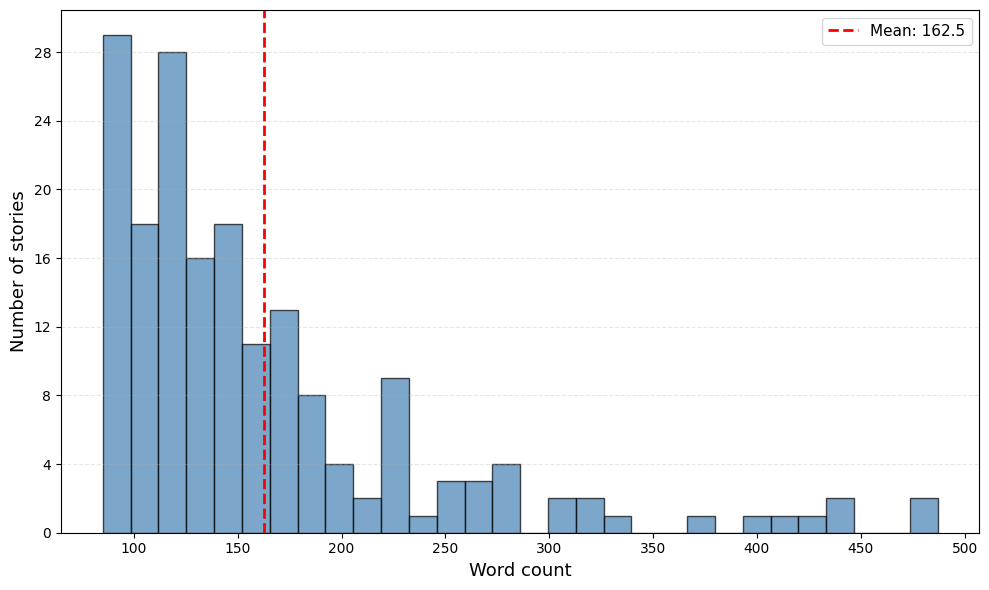

Figure saved as '/mimer/NOBACKUP/groups/naiss2025-22-1187/coherence-driven-humans/figures/word_count_distribution.pdf'


In [33]:
# Word count distribution
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

word_counts = payment_df['word_count'].values

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(word_counts, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(word_counts.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {word_counts.mean():.1f}')
ax.set_xlabel('Word count', fontsize=13)
ax.set_ylabel('Number of stories', fontsize=13)

# Set y-axis to show integer intervals only
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
output_path = '/mimer/NOBACKUP/groups/naiss2025-22-1187/coherence-driven-humans/figures/word_count_distribution.pdf'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved as '{output_path}'")